In [55]:
import h5py
import quimb as qu
import quimb.tensor as qtn
import numpy as np

import torch
from torch import optim
import tqdm
import cotengra as ctg

opti = ctg.ReusableHyperOptimizer(
    progbar=True,
    methods=['greedy'],
    reconf_opts={},
    max_repeats=32, 
    optlib='random',
    # directory=  # set this for persistent cache
)

### Read data

In [2]:
def read_data(data_name):
    with h5py.File("save_results/" + data_name + ".h5", "r") as f:
        keys = sorted(f.keys(), key=lambda x: int(x.split("_")[1]))
        print(keys)
        data = [np.transpose(f[key][:], (3,2,1,0)) for key in keys]

    return data

In [38]:
M1 = read_data("M1_a2")
M2 = read_data("M2_a2")

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']
['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']


In [13]:
for i in range(len(M1)):
    print(M1[i].shape)

(2, 2, 2, 1)
(4, 2, 2, 2)
(8, 2, 2, 4)
(16, 2, 2, 8)
(22, 2, 2, 16)
(16, 2, 2, 22)
(8, 2, 2, 16)
(4, 2, 2, 8)
(2, 2, 2, 4)
(1, 2, 2, 2)


In [ ]:
def array_to_lpdo(M1, tags):
    # convert input list of arrays to LPDO

    L = len(M1)

    inds = ('s0','e0','l0')
    first_tensor = M1[0][0,:,:,:]
    last_tensor = M1[-1][:,:,:,0]
    lpdo_1 = qtn.Tensor(data=first_tensor, inds=inds, tags=tags)

    for i in range(1, L):
        if i == L-1:
            inds = (f'l{i-1}', f's{i}', f'e{i}')
            current_tensor = qtn.Tensor(data=last_tensor, inds=inds, tags=tags)
        else:
            # bond, system, environment, bond
            inds = (f'l{i-1}', f's{i}', f'e{i}', f'l{i}')
            current_tensor = qtn.Tensor(data=M1[i], inds=inds, tags=tags)

        lpdo_1 = lpdo_1 & current_tensor

    return lpdo_1

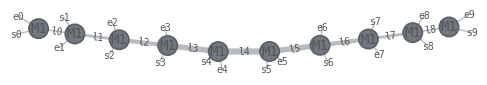

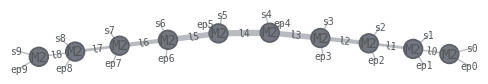

In [70]:
n = 10
tags = ('M1',)
lpdo_1 = array_to_lpdo(M1, tags)
lpdo_1.draw(show_inds='all')

tags = ('M2',)
lpdo_2 = array_to_lpdo(M2, tags)
lpdo_2 = lpdo_2.H
for i in range (n):
    lpdo_2 = lpdo_2.reindex({f'e{i}':f'ep{i}'})
lpdo_2.draw(show_inds='all')

### Circuit

In [ ]:
def staircase(circ, reverse=False,gate_round=None):

    regs = range(0, circ.N - 1)
    if reverse:
        regs = reversed(regs)
    
    for i in regs:
        u = qtn.array_ops.PArray(
            params=qu.randn((4, 4)),   # trainable parameters, random init
            fn=qtn.decomp.isometrize, # constraint function
            # shape=(2, 2, 2, 2)         # physical legs: two qubits
        )
        circ.apply_gate(
            u, i, i+1, gate_round=gate_round, parametrize=True
        )


def ansatz_circuit(n, depth, **kwargs):

    circ = qtn.Circuit(n, **kwargs)

    for r in range(depth):
        staircase(
            circ, gate_round=r, reverse=r % 2 == 0)

    return circ

In [60]:
n = 10
depth = 2

circ = ansatz_circuit(n, depth)
circ

ValueError: You cannot specify ``parametrize`` for raw gate, supply a ``PArray`` instead.

In [18]:
V = circ.uni

c:\Users\yliu\anaconda3\Lib\site-packages\quimb\tensor\circuit.py:2587: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


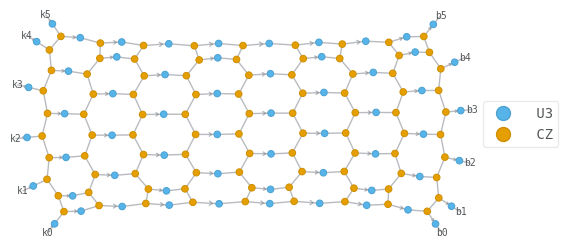

In [19]:
V.draw(color=['U3', gate2], show_inds=True)

In [22]:
V

TensorNetworkGenOperator(tensors=150, indices=201)

In [ ]:
def loss(V, U):
    return 1 - abs((V.H & U).contract(all, optimize='auto-hq')) / 2**n

# check our current unitary 'infidelity':
loss(V, U)

## Use Torch

In [68]:
def brickwall_unitary(psi, i_start, n_apply, list_u3, depth, n_Qbit, Qubit_ara,val_iden = 0,rand = False,start_layer=0):

    if n_Qbit==0: depth=1
    if n_Qbit==1: depth=1

    for r in range(depth):

        if (r+start_layer)%2==0:
            for i in range(i_start, i_start+n_Qbit, 2):
                # print("U_e", i, i + 1, n_apply)

                if rand == True:
                    G = qu.rand_uni(4, dtype=complex)
                    #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                else:
                    G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden
            
                psi.gate_(G, (i, i + 1), tags={'U',f'G{n_apply}', f'lay{Qubit_ara}',f'P{Qubit_ara}L{i}D{r}'})
                list_u3.append(f'G{n_apply}')
                n_apply+=1

        else:
            for i in range(i_start, i_start+n_Qbit-1, 2):
                # print("U_o", i+1, i + 2, n_apply)
         
                if rand == True:
                    G = qu.rand_uni(4, dtype=complex)
                    #G = qu.fsimg(1,1,1,1,1, dtype=complex)
                else:
                    G = qu.identity(4,dtype=complex)+qu.rand_uni(4, dtype=complex)*val_iden

                psi.gate_(G, (i+1, i + 2), tags={'U',f'G{n_apply}',f'lay{Qubit_ara}',f'P{Qubit_ara}L{i}D{r}'})
                list_u3.append(f'G{n_apply}')
                n_apply+=1

    return n_apply, list_u3


def qmps_f(L=16, in_depth=2, n_Qbit=3, data_type = complex, val_iden = 0,  canon="left",  seed_init=0, uni_list = None,rand = True,start_layer = 0):

    seed_val=seed_init
    list_u3=[]
    n_apply=0
    psi = qtn.MPS_computational_state('0' * (L))
    for i in range(L):
        t = psi[i]
        indx = 'k'+str(i)
        t.modify(left_inds=[indx])

    for t in  range(L):
        psi[t].modify(tags=[f"I{t}", "MPS"])


    if canon=="left":

        for i in range(0,L-n_Qbit,1):
            # only loop once?
            # print ("quibit", i+n_Qbit, n_Qbit)
            Qubit_ara=i+n_Qbit
            
            n_apply, list_u3=brickwall_unitary(psi, i, n_apply, list_u3, in_depth, n_Qbit, Qubit_ara,val_iden = 0, rand =rand,start_layer=start_layer)

    return psi.astype_('complex128')#, list_u3


def extract_unitary_circuit(psi_pqc, num_qubits):
    pqc = psi_pqc.tensors[num_qubits]
    for i in range (num_qubits+1,len(psi_pqc.tensors)):
        pqc = pqc&psi_pqc.tensors[i] #extrating the circuit part

    for i in range (num_qubits):
        pqc = pqc.reindex({f'k{i}':f'e{i}'})
        pqc = pqc.reindex({psi_pqc.tensors[i].inds[-1]:f'ep{i}'})

    return pqc

def full_contraction(pqc, lpdo_1, lpdo_2, is_show=0):
    if is_show == 1:
        (lpdo_1 & lpdo_2 & pqc).draw(['U','M2','M1'])

    return abs((lpdo_1 & lpdo_2 & pqc).contract(optimize=opti))

In [71]:
n = 10
num_qubits = n # physical 
depth = 4

psi_pqc = qmps_f(num_qubits, in_depth= depth, n_Qbit=num_qubits-1, canon="left",val_iden = 0.0,rand = False)
pqc = extract_unitary_circuit(psi_pqc, num_qubits)

full_contraction(pqc, lpdo_1, lpdo_2)

0.0

In [72]:
class TNModel(torch.nn.Module):

    def __init__(self, pqc, lpdo_1, lpdo_2):
        super().__init__()

        # extract the raw arrays and a skeleton of the TN
        params, self.skeleton = qtn.pack(pqc)
        # n.b. you might want to do extra processing here to e.g. store each
        # parameter as a reshaped matrix (from left_inds -> right_inds), for
        # some optimizers, and for some torch parametrizations
        self.torch_params = torch.nn.ParameterDict({
            # torch requires strings as keys
            str(i): torch.nn.Parameter(initial)
            for i, initial in params.items()
        })
        self._loss_fn = lambda x: full_contraction(x, lpdo_1, lpdo_2)
        
    def forward(self):
        # convert back to original int key format
        params = {int(i): p for i, p in self.torch_params.items()}
        # reconstruct the TN with the new parameters
        pqc = qtn.unpack(params, self.skeleton)
        # isometrize and then return the energy
        return self._loss_fn(pqc.isometrize(method='qr'))

In [65]:
pqc.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
lpdo_1.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))
lpdo_2.apply_to_arrays(lambda x: torch.tensor(x, dtype=torch.complex128))

model = TNModel(pqc, lpdo_1, lpdo_2)
lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer,step_size=200, gamma=0.5)
num_steps = 500
pbar = tqdm.tqdm(range(num_steps))
previous_loss = torch.inf
losses = []
for step in pbar:
    optimizer.zero_grad()
    loss = model.forward()
    losses.append(loss.detach().numpy())
    loss.backward()
    optimizer.step()
    pbar.set_description(f"Loss={loss} - LR={lr}")
    if step > 100 and torch.abs(previous_loss - loss) < 1e-10:
        print("Early stopping loss difference is smaller than 1e-10")
        break
    previous_loss = loss.clone()
print(f'traning loss: {loss}')

  0%|          | 0/500 [00:00<?, ?it/s]


RuntimeError: Unlike NumPy, torch.sign is not intended to support complex numbers. Please use torch.sgn instead.